Step 1: loading Fashion-MNIST
raw train: (60000, 28, 28) (60000,)
raw test : (10000, 28, 28) (10000,)

Step 2: preprocessing -> filter classes 0,1,2, flatten, normalize
filtered train: (18000, 784) (18000,)
filtered test : (3000, 784) (3000,)
classes in train: [0 1 2]
classes in test : [0 1 2]

Step 3: PCA with p = 10
ztr shape: (18000, 10)
zte shape: (3000, 10)
PCA matrix shape: (784, 10)
Reduced to 10 dims? True

Step 4: regression targets
train target shape: (18000,)
test target shape : (3000,)
target values in train: [0. 1. 2.]

Step 5: fit single regression stump on training set
best dim   : 2
best thr   : 1.4507965876719475
best SSR   : 6220.136243149647
left mean  : 1.382091482139971
right mean : 0.15961606825453253
left count : 12374
right count: 5626

Step 6: single stump test MSE
single stump test MSE: 0.3629439763726561
prediction shape: (3000,)

Step 7: bagging with 5 bootstrap datasets
stump=1 | dim=2 | thr=1.533171 | SSR=6333.086183 | oob count=6617
stump=2 | dim=2 | thr=

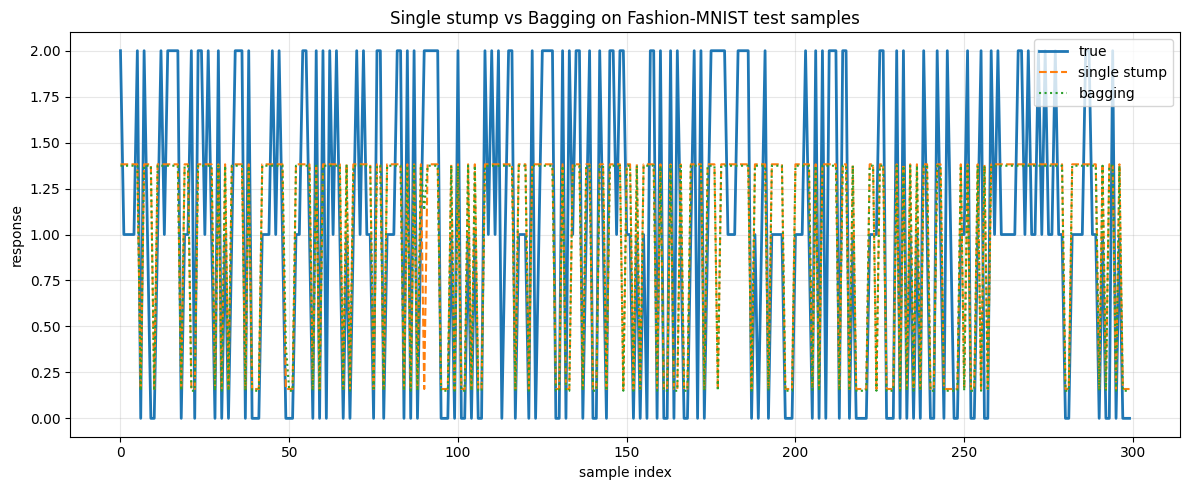

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist


# Step 1: load Fashion-MNIST
def load():
    (xtr, ytr), (xte, yte) = fashion_mnist.load_data()
    return xtr, ytr, xte, yte


# Step 2: preprocessing
# keep only classes 0,1,2 -> flatten -> normalize -> PCA later with p=10
def prep(xtr, ytr, xte, yte, cls=(0, 1, 2)):
    m1 = np.isin(ytr, cls)
    m2 = np.isin(yte, cls)

    xtr, ytr = xtr[m1], ytr[m1]
    xte, yte = xte[m2], yte[m2]

    xtr = xtr.reshape(len(xtr), -1).astype(float) / 255.0
    xte = xte.reshape(len(xte), -1).astype(float) / 255.0

    return xtr, ytr, xte, yte


# Step 3: PCA with p = 10
class PCA2:
    def __init__(self, k):
        self.k = k
        self.mu = None
        self.v = None

    def fit(self, X):
        self.mu = X.mean(axis=0)
        Xc = X - self.mu
        C = (Xc.T @ Xc) / Xc.shape[0]
        a, b = np.linalg.eigh(C)
        idx = np.argsort(a)[::-1]
        self.v = b[:, idx[:self.k]]
        return self

    def tr(self, X):
        return (X - self.mu) @ self.v

    def fit_tr(self, X):
        self.fit(X)
        return self.tr(X)


# Step 4: regression targets
def yy(y):
    return y.astype(float)


# Step 5: helpers
def mse(y, yp):
    return np.mean((y - yp) ** 2)


def ssr(y1, y2):
    s = 0.0
    if len(y1) > 0:
        m1 = np.mean(y1)
        s += np.sum((y1 - m1) ** 2)
    if len(y2) > 0:
        m2 = np.mean(y2)
        s += np.sum((y2 - m2) ** 2)
    return s


# Step 6: candidate thresholds = midpoints between consecutive sorted values
def mids(x):
    u = np.unique(np.sort(x))
    if len(u) < 2:
        return np.array([])
    return (u[:-1] + u[1:]) / 2.0


# Step 7: fit best regression stump
def stump(X, y):
    p = X.shape[1]
    best = {
        "j": None,
        "t": None,
        "s": np.inf,
        "ml": None,
        "mr": None,
        "yl": None,
        "yr": None
    }

    for j in range(p):
        ts = mids(X[:, j])
        if len(ts) == 0:
            continue

        for t in ts:
            ml = X[:, j] <= t
            mr = ~ml

            if np.sum(ml) == 0 or np.sum(mr) == 0:
                continue

            yl = y[ml]
            yr = y[mr]
            sv = ssr(yl, yr)

            if sv < best["s"]:
                best["j"] = int(j)
                best["t"] = float(t)
                best["s"] = float(sv)
                best["ml"] = ml
                best["mr"] = mr
                best["yl"] = float(np.mean(yl))
                best["yr"] = float(np.mean(yr))

    return best


# Step 8: stump prediction
def pred_stump(X, st):
    yp = np.empty(len(X), dtype=float)
    m = X[:, st["j"]] <= st["t"]
    yp[m] = st["yl"]
    yp[~m] = st["yr"]
    return yp


# Step 9: bootstrap sample
def boot(X, y, sd=None):
    rng = np.random.default_rng(sd)
    n = len(X)
    ib = rng.integers(0, n, size=n)  # sampled with replacement
    oo = np.setdiff1d(np.arange(n), np.unique(ib))  # OOB indices
    return X[ib], y[ib], ib, oo


# Step 10: bagging with 5 bootstrap datasets
def fit_bag(X, y, b=5, sd=42):
    arr = []
    oob = []

    for i in range(b):
        xb, yb, ib, oo = boot(X, y, sd + i)
        st = stump(xb, yb)
        arr.append(st)
        oob.append(oo)

    return arr, oob


def pred_many(X, arr):
    P = []
    for st in arr:
        P.append(pred_stump(X, st))
    return np.array(P)


def pred_avg(X, arr):
    P = pred_many(X, arr)
    return np.mean(P, axis=0)


# Step 11: OOB MSE for each model, then average OOB MSE across models
def oob_mse_per_model(X, y, arr, oob):
    vals = []

    for i, st in enumerate(arr):
        oo = oob[i]

        if len(oo) == 0:
            vals.append(np.nan)
            continue

        yp = pred_stump(X[oo], st)
        vals.append(mse(y[oo], yp))

    vals = np.array(vals, dtype=float)

    if np.all(np.isnan(vals)):
        avg = None
    else:
        avg = np.nanmean(vals)

    return vals, avg


# Step 12: full run
def main():
    cls = [0, 1, 2]

    print("Step 1: loading Fashion-MNIST")
    xr, yr, xs, ys = load()
    print("raw train:", xr.shape, yr.shape)
    print("raw test :", xs.shape, ys.shape)
    print()

    print("Step 2: preprocessing -> filter classes 0,1,2, flatten, normalize")
    xtr, ytr, xte, yte = prep(xr, yr, xs, ys, cls)
    print("filtered train:", xtr.shape, ytr.shape)
    print("filtered test :", xte.shape, yte.shape)
    print("classes in train:", np.unique(ytr))
    print("classes in test :", np.unique(yte))
    print()

    print("Step 3: PCA with p = 10")
    p = PCA2(10)
    ztr = p.fit_tr(xtr)
    zte = p.tr(xte)
    print("ztr shape:", ztr.shape)
    print("zte shape:", zte.shape)
    print("PCA matrix shape:", p.v.shape)
    print("Reduced to 10 dims?", ztr.shape[1] == 10 and zte.shape[1] == 10)
    print()

    print("Step 4: regression targets")
    ytr_reg = yy(ytr)
    yte_reg = yy(yte)
    print("train target shape:", ytr_reg.shape)
    print("test target shape :", yte_reg.shape)
    print("target values in train:", np.unique(ytr_reg))
    print()

    print("Step 5: fit single regression stump on training set")
    st = stump(ztr, ytr_reg)
    print("best dim   :", st["j"])
    print("best thr   :", st["t"])
    print("best SSR   :", st["s"])
    print("left mean  :", st["yl"])
    print("right mean :", st["yr"])
    print("left count :", int(np.sum(st["ml"])))
    print("right count:", int(np.sum(st["mr"])))
    print()

    print("Step 6: single stump test MSE")
    yp1 = pred_stump(zte, st)
    m1 = mse(yte_reg, yp1)
    print("single stump test MSE:", m1)
    print("prediction shape:", yp1.shape)
    print()

    print("Step 7: bagging with 5 bootstrap datasets")
    bag, oob = fit_bag(ztr, ytr_reg, b=5, sd=42)
    for i, st_i in enumerate(bag):
        print(
            f"stump={i+1} | dim={st_i['j']} | thr={st_i['t']:.6f} | "
            f"SSR={st_i['s']:.6f} | oob count={len(oob[i])}"
        )
    print()

    print("Step 8: OOB MSE for each stump and average OOB MSE")
    oob_vals, avg_oob = oob_mse_per_model(ztr, ytr_reg, bag, oob)
    for i, v in enumerate(oob_vals):
        print(f"stump={i+1} | OOB MSE={v}")
    print("average OOB MSE across all models:", avg_oob)
    print()

    print("Step 9: bagging test MSE")
    yp2 = pred_avg(zte, bag)
    m2 = mse(yte_reg, yp2)
    print("bagging test MSE:", m2)
    print("prediction shape:", yp2.shape)
    print()

    print("Step 10: comparison")
    print("single stump test MSE:", m1)
    print("bagging test MSE     :", m2)
    print("average OOB MSE      :", avg_oob)
    if m2 < m1:
        print("Bagging is better here because averaging reduces variance.")
    elif m2 > m1:
        print("Single stump is better on this run; bagging did not help enough.")
    else:
        print("Both methods are tied on this run.")
    print()

    print("Step 11: plot true response, single stump, and bagging on same figure")
    n = min(300, len(yte_reg))
    ix = np.arange(n)

    plt.figure(figsize=(12, 5))
    plt.plot(ix, yte_reg[:n], label="true", linewidth=2)
    plt.plot(ix, yp1[:n], label="single stump", linestyle="--")
    plt.plot(ix, yp2[:n], label="bagging", linestyle=":")
    plt.xlabel("sample index")
    plt.ylabel("response")
    plt.title("Single stump vs Bagging on Fashion-MNIST test samples")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()